## <span style='color:#ffb5c0'>**Exploratory Data Analysis, February 20th, 2026**

In [1]:
import pandas as pd
import numpy as np

In [ ]:
import holoviews as hv
import hvplot.pandas
from holoviews import opts
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf

In [3]:
data = pd.read_csv("ELA_data_2013_2023.csv")

### <span style='color:#ffb5c0'>**Data Feasibility Review & Data Cleaning/Preprocessing**

The initial data contains 626,462 rows and 18 columns. After filtering for years 2018, 2019, and 2022, the data contains 220,443 rows. Almost all columns do not have missing values, with the exception for school name. This is due to the data containing citywide and district level metrics, so school name is not applicable. 

The data was filtered to contain only years surrounding the COVID-19 pandemic, as this is the time period of interest. Unfortunately, data was not given for the years 2020 and 2021, due to cancelled and optional testing, respectively. All scores and levels (number and percentages) were converted to floats. The year was converted to an object. Groups with five or less tested students were suppressed with a value "s". Within this data, 58,872 rows are missing observations for scores and level breakdowns. These observations have been omitted.

In [4]:
from data_cleaning import cleaning_data, change_variable_type
school_data = cleaning_data(data) # filter for year, rename some vars

# convert num columns
cols = ['mean_scale_score','level_1_count','level_2_count','level_3_count', 'level_4_count', 'level_4_percentage', 'level_3_4_count',
        'level_1_percentage','level_2_percentage','level_3_percentage','level_4_percentage','level_3_4_percentage']
school_data = change_variable_type(school_data,cols)
# change year to ob
school_data['Year'] = school_data['Year'].astype('object')

In [5]:
# school_data.info()

In [6]:
# school_data_filtered = school_data[
#     ~(school_data['Report Category'].isin(['Citywide','School','Borough']))]

school_data_filtered = school_data[
    (school_data['Report Category'].isin(['District'])) &
    (school_data['Grade'] == 'All Grades') &
    (school_data['Student Category'] == 'All Students')
    ]





### <span style='color:#ffb5c0'>**Ethics and Bias Considerations** </span>

This data is very heavily balanced regarding different socioeconomic categories. There are some disparities with gender by ethnicity, however these indicators will not be used. The same can be said for grade, where there is sufficient distribution. 

### <span style='color:#ffb5c0'> **Poverty Data, for District Level Information**

New York City OpenData Demographic Snapshot <br>
https://data.cityofnewyork.us/Education/2017-18-2021-22-Demographic-Snapshot/c7ru-d68s/about_data


In [19]:
district_poverty = pd.read_excel('Demographic_Snapshot_2017-18_to_2021-22__Public_.xlsx', sheet_name = 'District')

In [20]:
district_poverty

,Administrative District,Year,Total Enrollment,Grade 3K,Grade PK (Half Day & Full Day),Grade K,Grade 1,Grade 2,Grade 3,Grade 4,...,% White,# Missing Race/Ethnicity Data,% Missing Race/Ethnicity Data,# Students with Disabilities,% Students with Disabilities,# English Language Learners,% English Language Learners,# Poverty,% Poverty,Economic Need Index
0,1,2017-18,11632,0,800,851,846,854,862,839,...,0.173831,29,0.002493,2528,0.217331,1016,0.087345,7682,0.660420,0.670163
1,1,2018-19,11376,0,759,799,850,816,838,839,...,0.179764,38,0.003340,2597,0.228288,966,0.084916,7314,0.642932,0.661232
2,1,2019-20,11506,211,749,812,782,848,813,818,...,0.178689,126,0.010951,2593,0.225361,919,0.079871,7419,0.644794,0.676958
3,1,2020-21,11021,209,623,728,762,746,787,775,...,0.180746,101,0.009164,2501,0.226930,919,0.083386,7087,0.643045,0.670118
4,1,2021-22,10327,347,524,685,701,686,680,707,...,0.180014,29,0.002808,2355,0.228043,814,0.078823,6463,0.625835,0.653216
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
170,84,2017-18,113528,0,533,11445,12016,11447,10857,10032,...,0.043848,280,0.002466,20002,0.176186,7859,0.069225,92292,0.812945,0.755627
171,84,2018-19,119551,0,524,12001,12103,11765,10955,10196,...,0.043488,281,0.002350,21281,0.178008,8264,0.069125,96585,0.807898,0.753894
172,84,2019-20,129668,0,572,13217,13130,12313,11798,10928,...,0.042539,269,0.002075,23257,0.179358,9256,0.071382,104010,0.802125,0.781033
173,84,2020-21,138648,0,636,13122,13775,13331,12526,11982,...,0.043650,445,0.003210,25299,0.182469,10755,0.077571,112037,0.808068,0.780144


In [21]:
cols_to_keep = ['Administrative District','Year','% Poverty']
district_poverty_filtered = district_poverty[
    (district_poverty['Year'] == '2018-19') & 
    ~(district_poverty['Administrative District'].isin([75,79,84]))][cols_to_keep]

In [22]:
district_poverty_filtered['Administrative District'] = district_poverty_filtered['Administrative District'].astype('object')

In [23]:
district_poverty_filtered['% Poverty'] = district_poverty_filtered['% Poverty'].replace({'Above 95%':'0.95'})

In [24]:
district_level_data = school_data[
    (school_data['Report Category'].isin(['District'])) &
    (school_data['Grade'] == 'All Grades') &
    (school_data['Student Category'] == 'All Students')
    ]


In [25]:
district_level_data= district_level_data.rename(columns = {'Geographic Subdivision':'Administrative District'})

In [26]:
district_poverty_filtered

,Administrative District,Year,% Poverty
1,1,2018-19,0.642932
6,2,2018-19,0.531863
11,3,2018-19,0.489436
16,4,2018-19,0.813852
21,5,2018-19,0.818708
26,6,2018-19,0.853175
31,7,2018-19,0.916370
36,8,2018-19,0.832162
41,9,2018-19,0.924517
46,10,2018-19,0.831589


In [27]:
district_level_data['Administrative District'] = district_level_data['Administrative District'].astype(str)
district_poverty_filtered['Administrative District'] = district_poverty_filtered['Administrative District'].astype(str)

In [28]:
merged_dis= district_level_data.merge(
    district_poverty_filtered[['Administrative District', '% Poverty']],  # keep only needed columns
    on='Administrative District',
    how='left'
)


In [29]:
merged_dis

,Report Category,Administrative District,school_name,Grade,Year,Student Category,number_tested,mean_scale_score,level_1_count,level_1_percentage,level_2_count,level_2_percentage,level_3_count,level_3_percentage,level_4_count,level_4_percentage,level_3_4_count,level_3_4_percentage,% Poverty
0,District,1,NaN,All Grades,2022,All Students,3283,605.0,650.0,19.8,871.0,26.5,793.0,24.2,969.0,29.5,1762.0,53.7,0.642932
1,District,1,NaN,All Grades,2019,All Students,4103,605.0,794.0,19.4,1055.0,25.7,1079.0,26.3,1175.0,28.6,2254.0,54.9,0.642932
2,District,1,NaN,All Grades,2018,All Students,4183,606.0,789.0,18.9,1129.0,27.0,1137.0,27.2,1128.0,27.0,2265.0,54.1,0.642932
3,District,2,NaN,All Grades,2022,All Students,12669,614.0,1024.0,8.1,2228.0,17.6,3932.0,31.0,5485.0,43.3,9417.0,74.3,0.531863
4,District,2,NaN,All Grades,2019,All Students,15264,613.0,1325.0,8.7,2528.0,16.6,5076.0,33.3,6335.0,41.5,11411.0,74.8,0.531863
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
91,District,31,NaN,All Grades,2019,All Students,26058,603.0,5243.0,20.1,7077.0,27.2,7901.0,30.3,5837.0,22.4,13738.0,52.7,0.578126
92,District,31,NaN,All Grades,2018,All Students,26019,604.0,4763.0,18.3,7474.0,28.7,8057.0,31.0,5725.0,22.0,13782.0,53.0,0.578126
93,District,32,NaN,All Grades,2022,All Students,4023,595.0,1340.0,33.3,1228.0,30.5,906.0,22.5,549.0,13.6,1455.0,36.2,0.890199
94,District,32,NaN,All Grades,2019,All Students,5258,594.0,1715.0,32.6,1681.0,32.0,1228.0,23.4,634.0,12.1,1862.0,35.4,0.890199


In [ ]:
def categorize_poverty(row):
    """Categorizes poverty based on the % Poverty column and a poverty threshold."""
    if row['% Poverty'] >= nyc_poverty_percent:
        return '1'
    else:
        return '0'
    
nyc_poverty_percent = 0.60

In [ ]:
# convert % Poverty to float and create poverty category
merged_dis['% Poverty'] = merged_dis['% Poverty'].astype(float)
merged_dis['Poverty_Category'] = merged_dis.apply(categorize_poverty, axis=1) 
merged_dis['% Poverty'] = merged_dis['% Poverty'].round(3)

In [ ]:
# plots for new poverty category variable
p_data_dis= (merged_dis.groupby(['Year','Poverty_Category'])[
    ['level_1_percentage',
     'level_2_percentage',
     'level_3_percentage',
     'level_4_percentage',
     'level_3_4_percentage',
     'mean_scale_score'
     ]
].mean())

p1= p_data_dis.hvplot.line(
    x = 'Year',
    y = 'level_1_percentage',
    by = 'Poverty_Category'
).opts(ylabel = 'Level 1 %')


p2 = p_data_dis.hvplot.line(
    x = 'Year',
    y = 'level_2_percentage',
    by = 'Poverty_Category'
).opts(ylabel = 'Level 2 %')

p3 = p_data_dis.hvplot.line(
    x = 'Year',
    y = 'level_3_percentage',
    by = 'Poverty_Category'
).opts(ylabel = 'Level 3 %')

p4 = p_data_dis.hvplot.line(
    x = 'Year',
    y = 'level_4_percentage',
    by = 'Poverty_Category'
).opts(ylabel = 'Level 4 %')

p5 = p_data_dis.hvplot.line(
    x = 'Year',
    y = 'level_3_4_percentage',
    by = 'Poverty_Category'
).opts(ylabel = 'Level 3 & 4 %')

p6 = p_data_dis.hvplot.line(
    x = 'Year',
    y = 'mean_scale_score',
    by = 'Poverty_Category'
).opts(ylabel = 'Mean Scale Score')


layout1 = (p1 + p2 + p3 + p4 + p5 + p6).cols(2)
layout1



:Layout
   .NdOverlay.I   :NdOverlay   [Poverty_Category]
      :Curve   [Year]   (level_1_percentage)
   .NdOverlay.II  :NdOverlay   [Poverty_Category]
      :Curve   [Year]   (level_2_percentage)
   .NdOverlay.III :NdOverlay   [Poverty_Category]
      :Curve   [Year]   (level_3_percentage)
   .NdOverlay.IV  :NdOverlay   [Poverty_Category]
      :Curve   [Year]   (level_4_percentage)
   .NdOverlay.V   :NdOverlay   [Poverty_Category]
      :Curve   [Year]   (level_3_4_percentage)
   .NdOverlay.VI  :NdOverlay   [Poverty_Category]
      :Curve   [Year]   (mean_scale_score)

### <span style='color:#ffb5c0'> **Poverty Data, for School Level Information**

New York City OpenData Demographic Snapshot <br>
https://data.cityofnewyork.us/Education/2017-18-2021-22-Demographic-Snapshot/c7ru-d68s/about_data


In [33]:
school_poverty = pd.read_excel('Demographic_Snapshot_2017-18_to_2021-22__Public_.xlsx', sheet_name = 'School')

In [34]:
cols_to_keep = ['DBN','School Name','Year','% Poverty']
school_poverty_filtered = school_poverty[
    (school_poverty['Year'] == '2018-19')][cols_to_keep]


In [35]:
# all schools w poverty levels > 0.95 were labelled as "Above 95%", puts 0.95 inplace
school_poverty_filtered['% Poverty'] = school_poverty_filtered['% Poverty'].replace({'Above 95%':'0.95'})

**Citywide Poverty % for 2018-19 school year was 74%**

In [36]:
school_level_data = school_data[
    (school_data['Report Category'].isin(['School'])) &
    (school_data['Grade'] == 'All Grades') &
    (school_data['Student Category'] == 'All Students')
    ]



In [37]:
school_poverty_filtered['School Name'].nunique()

1821

In [38]:
school_level_data['school_name'].nunique()  

1119

In [39]:
school_level_data= school_level_data.rename(columns = {'Geographic Subdivision':'DBN'})

In [40]:
merged_school= school_level_data.merge(
    school_poverty_filtered[['DBN', '% Poverty']],  # keep only needed columns
    on='DBN',
    how='left'
)


In [41]:
def categorize_poverty(row):
    if row['% Poverty'] >= nyc_poverty_percent:
        return '1'
    else:
        return '0'
    
nyc_poverty_percent = 0.60

In [42]:
merged_school['% Poverty'] = merged_school['% Poverty'].astype(float)

In [43]:
merged_school['Poverty_Category'] = merged_school.apply(categorize_poverty, axis=1) 
merged_school['% Poverty'] = merged_school['% Poverty'].round(3)

In [44]:
p_data= (merged_school.groupby(['Year','Poverty_Category'])[
    ['level_1_percentage',
     'level_2_percentage',
     'level_3_percentage',
     'level_4_percentage',
     'level_3_4_percentage',
     'mean_scale_score'
     ]
].mean())

p1= p_data.hvplot.line(
    x = 'Year',
    y = 'level_1_percentage',
    by = 'Poverty_Category'
).opts(ylabel = 'Level 1 %', title = 'School Level 1 % Data with Poverty Categories')


p2 = p_data.hvplot.line(
    x = 'Year',
    y = 'level_2_percentage',
    by = 'Poverty_Category'
).opts(ylabel = 'Level 2 %', title = 'School Level 2 % Data with Poverty Categories')

p3 = p_data.hvplot.line(
    x = 'Year',
    y = 'level_3_percentage',
    by = 'Poverty_Category'
).opts(ylabel = 'Level 3 %', title = 'School Level 3 % Data with Poverty Categories')

p4 = p_data.hvplot.line(
    x = 'Year',
    y = 'level_4_percentage',
    by = 'Poverty_Category'
).opts(ylabel = 'Level 4 %', title = 'School Level 4 % Data with Poverty Categories')

p5 = p_data.hvplot.line(
    x = 'Year',
    y = 'level_3_4_percentage',
    by = 'Poverty_Category'
).opts(ylabel = 'Level 3 & 4 %', title = 'School Level 3 & 4 % Data with Poverty Categories')

# p6 = p_data.hvplot.line(
#     x = 'Year',
#     y = 'mean_scale_score',
#     by = 'Poverty_Category'
# ).opts(ylabel = 'Mean Scale Score', title = 'School Mean Scale Score Data with Poverty Categories')


layout1 = (p1 + p2 + p3 + p4 + p5).cols(2)
layout1



:Layout
   .NdOverlay.I   :NdOverlay   [Poverty_Category]
      :Curve   [Year]   (level_1_percentage)
   .NdOverlay.II  :NdOverlay   [Poverty_Category]
      :Curve   [Year]   (level_2_percentage)
   .NdOverlay.III :NdOverlay   [Poverty_Category]
      :Curve   [Year]   (level_3_percentage)
   .NdOverlay.IV  :NdOverlay   [Poverty_Category]
      :Curve   [Year]   (level_4_percentage)
   .NdOverlay.V   :NdOverlay   [Poverty_Category]
      :Curve   [Year]   (level_3_4_percentage)

In [45]:
p6

:NdOverlay   [Poverty_Category]
   :Curve   [Year]   (mean_scale_score)

In [46]:
merged_school.groupby(['Year','Poverty_Category'])['mean_scale_score'].mean().unstack()

Poverty_Category,0,1
Year,,
2018,613.051402,597.430365
2019,612.069444,596.539933
2022,611.958716,596.989807


In [47]:
merged_school.hvplot.hist(
    y = '% Poverty',
    by = 'Year',
    bins = 30,
    title = 'Poverty % Distribution - 2019 and 2022'
)

:NdOverlay   [Year]
   :Histogram   [% Poverty]   (Count)

Poverty percentage is left-skewed. This does not entirely effect TWFE DID analysis, normality is not an assumption.

In [48]:
merged_school.hvplot.scatter(
    x  = '% Poverty',
    y = 'mean_scale_score',
    by = 'Year'
).opts(xlabel='Poverty %', ylabel='Mean Score', title = 'Mean Score by Year, with Poverty Data', width = 900, height = 600)

:NdOverlay   [Year]
   :Scatter   [% Poverty]   (mean_scale_score)

In [57]:
merged_school

,Report Category,DBN,school_name,Grade,Year,Student Category,number_tested,mean_scale_score,level_1_count,level_1_percentage,level_2_count,level_2_percentage,level_3_count,level_3_percentage,level_4_count,level_4_percentage,level_3_4_count,level_3_4_percentage,% Poverty,Poverty_Category
0,School,01M015,P.S. 015 ROBERTO CLEMENTE,All Grades,2022,All Students,74,596.0,21.0,28.4,30.0,40.5,13.0,17.6,10.0,13.5,23.0,31.1,0.845,1
1,School,01M015,P.S. 015 ROBERTO CLEMENTE,All Grades,2019,All Students,70,606.0,7.0,10.0,21.0,30.0,33.0,47.1,9.0,12.9,42.0,60.0,0.845,1
2,School,01M015,P.S. 015 ROBERTO CLEMENTE,All Grades,2018,All Students,67,610.0,5.0,7.5,17.0,25.4,31.0,46.3,14.0,20.9,45.0,67.2,0.845,1
3,School,01M020,P.S. 020 ANNA SILVER,All Grades,2022,All Students,110,589.0,48.0,43.6,36.0,32.7,15.0,13.6,11.0,10.0,26.0,23.6,0.678,1
4,School,01M020,P.S. 020 ANNA SILVER,All Grades,2019,All Students,197,597.0,50.0,25.4,69.0,35.0,58.0,29.4,20.0,10.2,78.0,39.6,0.678,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3320,School,32K554,ALL CITY LEADERSHIP SECONDARY SCHOOL,All Grades,2019,All Students,173,621.0,4.0,2.3,11.0,6.4,45.0,26.0,113.0,65.3,158.0,91.3,0.816,1
3321,School,32K554,ALL CITY LEADERSHIP SECONDARY SCHOOL,All Grades,2018,All Students,178,621.0,1.0,0.6,11.0,6.2,54.0,30.3,112.0,62.9,166.0,93.3,0.816,1
3322,School,32K562,EVERGREEN MIDDLE SCHOOL FOR URBAN EXPLORATION,All Grades,2022,All Students,245,596.0,76.0,31.0,71.0,29.0,63.0,25.7,35.0,14.3,98.0,40.0,0.949,1
3323,School,32K562,EVERGREEN MIDDLE SCHOOL FOR URBAN EXPLORATION,All Grades,2019,All Students,323,593.0,113.0,35.0,114.0,35.3,73.0,22.6,23.0,7.1,96.0,29.7,0.949,1


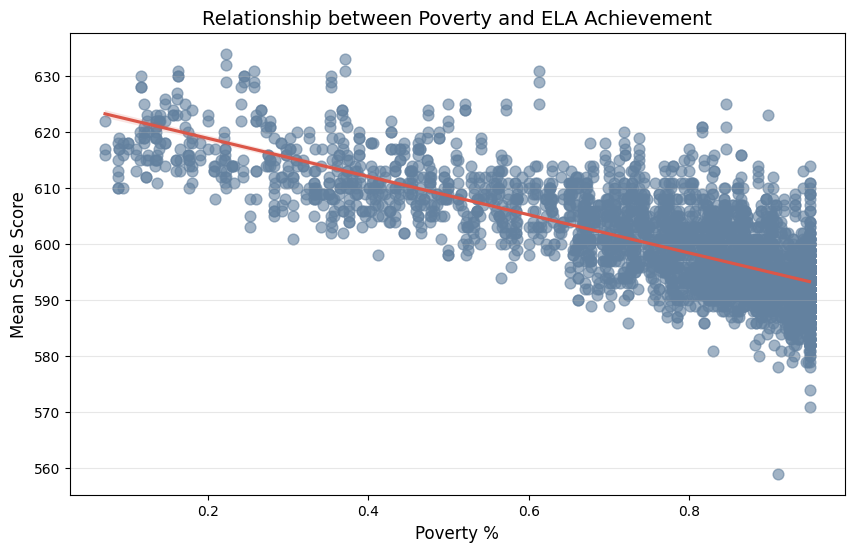

In [ ]:
# plot for relationship between continuous poverty and mean scale score
plt.figure(figsize=(10, 6))

sns.regplot(data=merged_school, x='% Poverty', y='mean_scale_score',
            scatter_kws={'color': "#63819f", 'alpha': 0.6, 's': 60},
            line_kws={'color': "#db5648"})

# labeling and titles
plt.title('Relationship between Poverty and ELA Achievement', fontsize=14)
plt.xlabel('Poverty %', fontsize=12)
plt.ylabel('Mean Scale Score', fontsize=12)
plt.grid(axis='y', alpha=0.3)

plt.show()
